In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("./housing.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [41]:
lat_long = df[['longitude', 'latitude']]
lat, longg = df.latitude, df.longitude

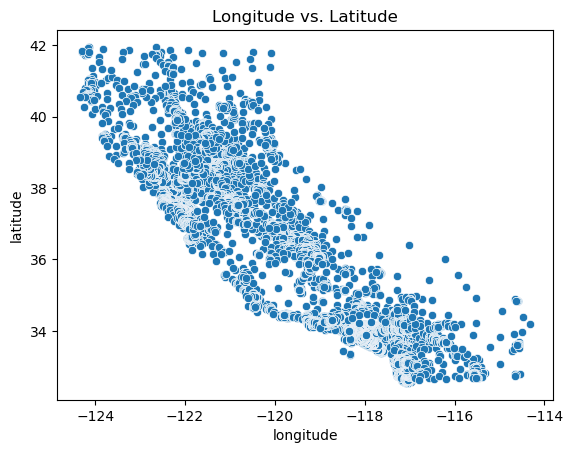

In [25]:
sns.scatterplot(data=df, x='longitude', y='latitude')
plt.title('Longitude vs. Latitude')
plt.show()

In [193]:
from sklearn.cluster import DBSCAN

X =  lat_long.to_numpy()
model = DBSCAN(min_samples=15, eps=0.2).fit(X)

In [201]:
model.labels_

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [205]:
df['Cluster'] = model.labels_
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,Cluster
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,0
...,...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND,0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND,0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND,0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND,0


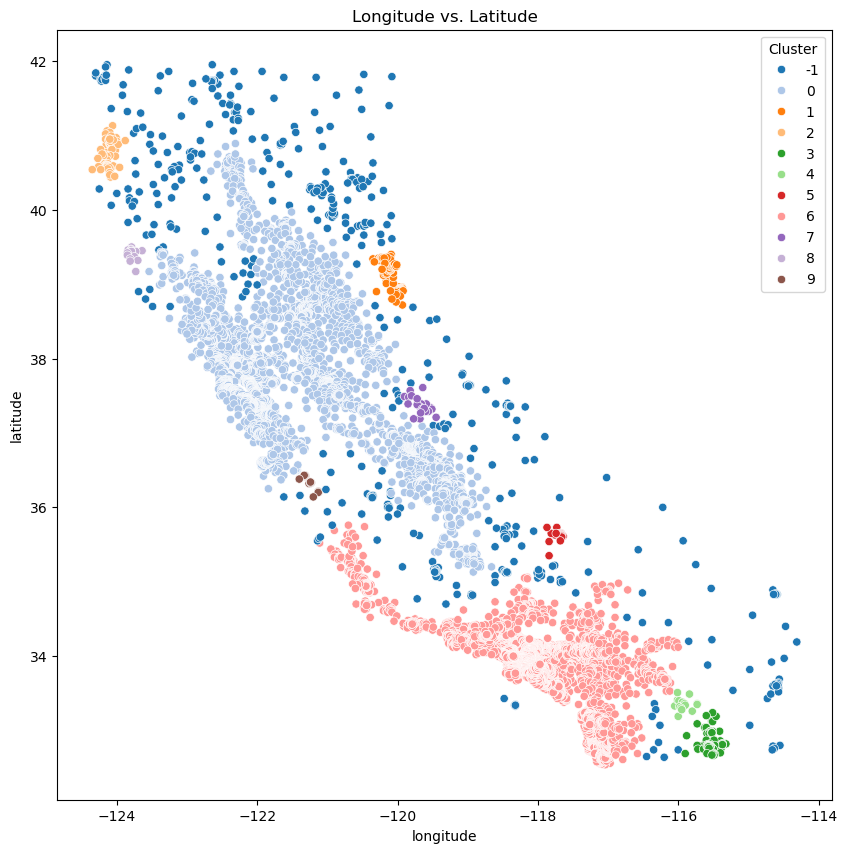

In [226]:
plt.figure(figsize=(10, 10))
sns.scatterplot(data=df, x='longitude', y='latitude', hue=df.Cluster, palette='tab20')
plt.title('Longitude vs. Latitude')
plt.show()

In [214]:
df.Cluster.value_counts()

Cluster
 6    11249
 0     8545
-1      443
 2      109
 1       98
 3       98
 5       27
 7       22
 8       18
 9       16
 4       15
Name: count, dtype: int64

In [228]:
from sklearn.metrics import silhouette_score
silhouette_score(X, model.labels_)

0.21921057256832627

In [252]:
# يقوم بإنشاء مصفوفة (أو سلسلة) من الأعداد ذات التوزيع المنتظم بين 0.01 و 1، وعدد هذه القيم هو 15 بالضبط
epsilons = np.linspace(0.01, 4, num=20)
epsilons

array([0.01, 0.22, 0.43, 0.64, 0.85, 1.06, 1.27, 1.48, 1.69, 1.9 , 2.11,
       2.32, 2.53, 2.74, 2.95, 3.16, 3.37, 3.58, 3.79, 4.  ])

In [340]:
epsilons = np.linspace(0.1, 1, num=20)
epsilons

array([0.1       , 0.14736842, 0.19473684, 0.24210526, 0.28947368,
       0.33684211, 0.38421053, 0.43157895, 0.47894737, 0.52631579,
       0.57368421, 0.62105263, 0.66842105, 0.71578947, 0.76315789,
       0.81052632, 0.85789474, 0.90526316, 0.95263158, 1.        ])

In [349]:
min_samples = np.arange(2, 20, step=1)
min_samples

array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19])

In [350]:
# يقوم بإنشاء جميع التوليفات الممكنة (Cartesian product) بين عناصر القائمتين epsilons و min_samples
import itertools

combinations = list(itertools.product(epsilons, min_samples))
combinations

[(0.1, 2),
 (0.1, 3),
 (0.1, 4),
 (0.1, 5),
 (0.1, 6),
 (0.1, 7),
 (0.1, 8),
 (0.1, 9),
 (0.1, 10),
 (0.1, 11),
 (0.1, 12),
 (0.1, 13),
 (0.1, 14),
 (0.1, 15),
 (0.1, 16),
 (0.1, 17),
 (0.1, 18),
 (0.1, 19),
 (0.1473684210526316, 2),
 (0.1473684210526316, 3),
 (0.1473684210526316, 4),
 (0.1473684210526316, 5),
 (0.1473684210526316, 6),
 (0.1473684210526316, 7),
 (0.1473684210526316, 8),
 (0.1473684210526316, 9),
 (0.1473684210526316, 10),
 (0.1473684210526316, 11),
 (0.1473684210526316, 12),
 (0.1473684210526316, 13),
 (0.1473684210526316, 14),
 (0.1473684210526316, 15),
 (0.1473684210526316, 16),
 (0.1473684210526316, 17),
 (0.1473684210526316, 18),
 (0.1473684210526316, 19),
 (0.19473684210526315, 2),
 (0.19473684210526315, 3),
 (0.19473684210526315, 4),
 (0.19473684210526315, 5),
 (0.19473684210526315, 6),
 (0.19473684210526315, 7),
 (0.19473684210526315, 8),
 (0.19473684210526315, 9),
 (0.19473684210526315, 10),
 (0.19473684210526315, 11),
 (0.19473684210526315, 12),
 (0.1947368421

In [351]:
N = len(combinations)
N

360

In [398]:
def get_scores_and_labels(combinations, X):
  scores = []
  all_labels_list = []

  for i, (eps, num_samples) in enumerate(combinations):
    dbscan_cluster_model = DBSCAN(eps=eps, min_samples=num_samples).fit(X)
    labels = dbscan_cluster_model.labels_
    labels_set = set(labels)
    num_clusters = len(labels_set)
    if -1 in labels_set:
      num_clusters -= 1
    
    if (num_clusters < 2) or (num_clusters > 50):
      scores.append(-10)
      all_labels_list.append('bad')
      c = (eps, num_samples)
      print(f"Combination {c} on iteration {i+1} of {N} has {num_clusters} clusters. Moving on")
      continue
    
    scores.append(silhouette_score(X, labels))
    all_labels_list.append(labels)
    print(f"Index: {i}, Score: {scores[-1]}, Labels: {all_labels_list[-1]}, NumClusters: {num_clusters}")

  best_index = np.argmax(scores)
  best_parameters = combinations[best_index]
  best_labels = all_labels_list[best_index]
  best_score = scores[best_index]

  return {'best_epsilon': best_parameters[0],
          'best_min_samples': best_parameters[1], 
          'best_labels': best_labels,
          'best_score': best_score}

best_dict = get_scores_and_labels(combinations, X)

Combination (0.1, 2) on iteration 1 of 360 has 89 clusters. Moving on
Combination (0.1, 3) on iteration 2 of 360 has 64 clusters. Moving on
Combination (0.1, 4) on iteration 3 of 360 has 61 clusters. Moving on
Combination (0.1, 5) on iteration 4 of 360 has 58 clusters. Moving on
Combination (0.1, 6) on iteration 5 of 360 has 54 clusters. Moving on
Index: 5, Score: 0.17133781997548447, Labels: [ 0  0  0 ... -1 -1 -1], NumClusters: 48
Index: 6, Score: 0.14213412332438294, Labels: [ 0  0  0 ... -1 -1 -1], NumClusters: 46
Index: 7, Score: 0.15205895024513402, Labels: [ 0  0  0 ... -1 -1 -1], NumClusters: 41
Index: 8, Score: 0.14870053900687832, Labels: [ 0  0  0 ... -1 -1 -1], NumClusters: 39
Index: 9, Score: 0.30293190518949, Labels: [ 0  0  0 ... -1 -1 -1], NumClusters: 36
Index: 10, Score: 0.3057220434978123, Labels: [ 0  0  0 ... -1 -1 -1], NumClusters: 35
Index: 11, Score: 0.27949501361550394, Labels: [ 0  0  0 ... -1 -1 -1], NumClusters: 35
Index: 12, Score: 0.2565448219682429, Label

In [399]:
best_dict

{'best_epsilon': 0.2894736842105263,
 'best_min_samples': 17,
 'best_labels': array([0, 0, 0, ..., 0, 0, 0], dtype=int64),
 'best_score': 0.3962302110516189}

In [404]:
df['Cluster'] = best_dict['best_labels']
df['Cluster'] .value_counts()

Cluster
 2    11398
 0     8816
-1      249
 1      118
 4       31
 3       28
Name: count, dtype: int64

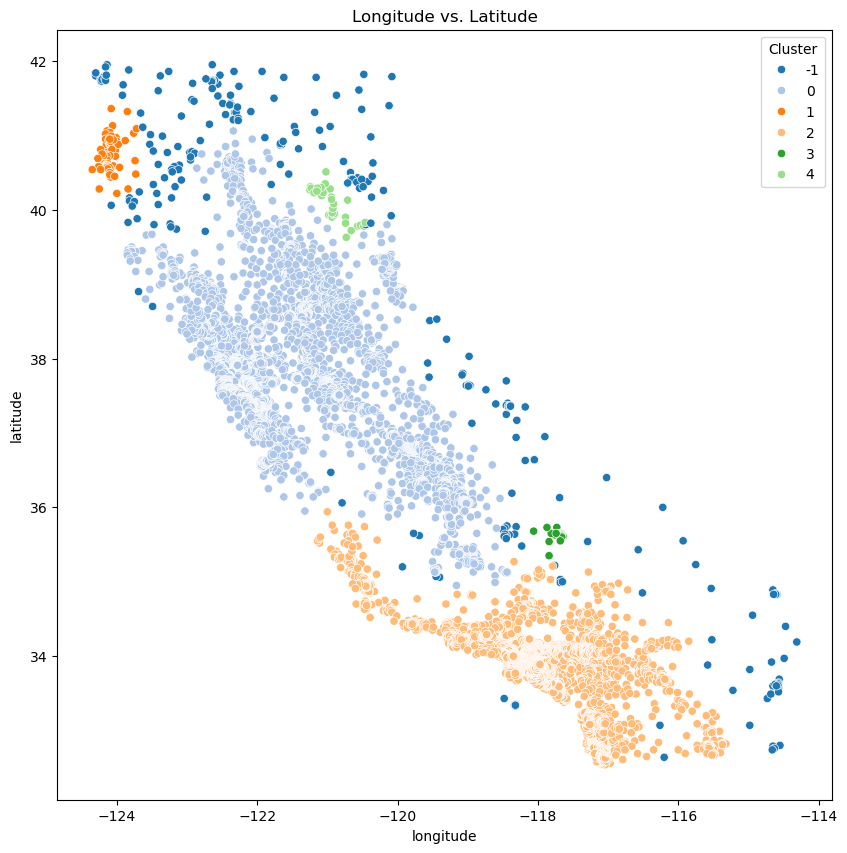

In [406]:
plt.figure(figsize=(10, 10))
sns.scatterplot(data=df, x='longitude', y='latitude', hue=df.Cluster, palette='tab20')
plt.title('Longitude vs. Latitude')
plt.show()

In [280]:
model = DBSCAN(min_samples=18, eps=0.33).fit(X)
silhouette_score(X, model.labels_)

0.6668632737425229

In [302]:
df['Cluster2'] = model.labels_
df['Cluster2'].value_counts()

Cluster2
 0    20329
-1      163
 1      120
 2       28
Name: count, dtype: int64

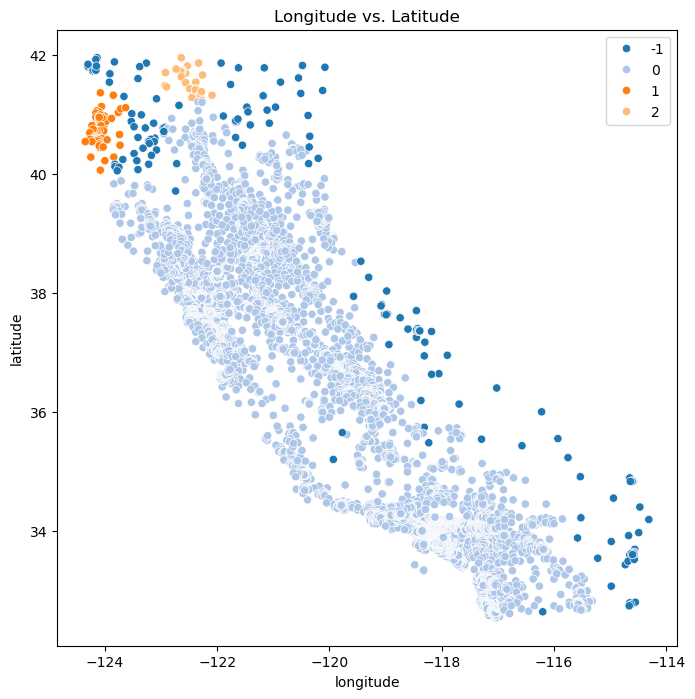

In [288]:
plt.figure(figsize=(8, 8))
sns.scatterplot(data=df, x='longitude', y='latitude', hue=model.labels_, palette='tab20')
plt.title('Longitude vs. Latitude')
plt.show()

In [324]:
df.T

,0,1,2,3,4,5,6,7,8,9,...,20630,20631,20632,20633,20634,20635,20636,20637,20638,20639
longitude,-122.23,-122.22,-122.24,-122.25,-122.25,-122.25,-122.25,-122.25,-122.26,-122.25,...,-121.32,-121.4,-121.45,-121.53,-121.56,-121.09,-121.21,-121.22,-121.32,-121.24
latitude,37.88,37.86,37.85,37.85,37.85,37.85,37.84,37.84,37.84,37.84,...,39.29,39.33,39.26,39.19,39.27,39.48,39.49,39.43,39.43,39.37
housing_median_age,41.0,21.0,52.0,52.0,52.0,52.0,52.0,52.0,42.0,52.0,...,11.0,15.0,15.0,27.0,28.0,25.0,18.0,17.0,18.0,16.0
total_rooms,880.0,7099.0,1467.0,1274.0,1627.0,919.0,2535.0,3104.0,2555.0,3549.0,...,2640.0,2655.0,2319.0,2080.0,2332.0,1665.0,697.0,2254.0,1860.0,2785.0
total_bedrooms,129.0,1106.0,190.0,235.0,280.0,213.0,489.0,687.0,665.0,707.0,...,505.0,493.0,416.0,412.0,395.0,374.0,150.0,485.0,409.0,616.0
population,322.0,2401.0,496.0,558.0,565.0,413.0,1094.0,1157.0,1206.0,1551.0,...,1257.0,1200.0,1047.0,1082.0,1041.0,845.0,356.0,1007.0,741.0,1387.0
households,126.0,1138.0,177.0,219.0,259.0,193.0,514.0,647.0,595.0,714.0,...,445.0,432.0,385.0,382.0,344.0,330.0,114.0,433.0,349.0,530.0
median_income,8.3252,8.3014,7.2574,5.6431,3.8462,4.0368,3.6591,3.12,2.0804,3.6912,...,3.5673,3.5179,3.125,2.5495,3.7125,1.5603,2.5568,1.7,1.8672,2.3886
median_house_value,452600.0,358500.0,352100.0,341300.0,342200.0,269700.0,299200.0,241400.0,226700.0,261100.0,...,112000.0,107200.0,115600.0,98300.0,116800.0,78100.0,77100.0,92300.0,84700.0,89400.0
ocean_proximity,NEAR BAY,NEAR BAY,NEAR BAY,NEAR BAY,NEAR BAY,NEAR BAY,NEAR BAY,NEAR BAY,NEAR BAY,NEAR BAY,...,INLAND,INLAND,INLAND,INLAND,INLAND,INLAND,INLAND,INLAND,INLAND,INLAND


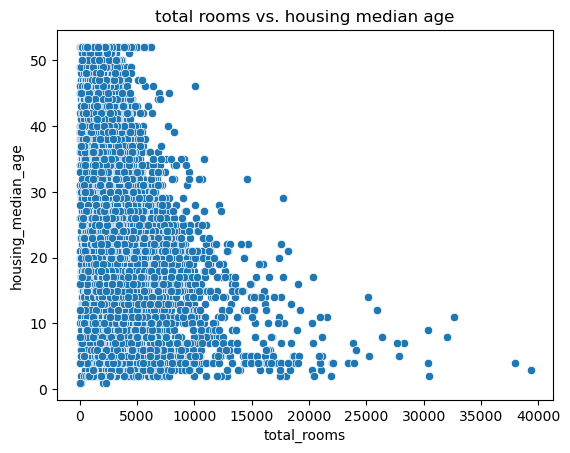

In [332]:
sns.scatterplot(data=df, x=df.total_rooms, y=df.housing_median_age)
plt.title('total rooms vs. housing median age')
plt.show()

In [336]:
X2 = df[['total_rooms', 'housing_median_age']]

In [358]:
best_dict2 = get_scores_and_labels(combinations, X2)

Combination (0.1, 2) on iteration 1 of 360 has 1199 clusters. Moving on
Combination (0.1, 3) on iteration 2 of 360 has 98 clusters. Moving on
Index: 2, Score: -0.6866230789255796, Labels: [-1 -1 -1 ... -1 -1 -1], NumClusters: 11
Combination (0.1, 5) on iteration 4 of 360 has 0 clusters. Moving on
Combination (0.1, 6) on iteration 5 of 360 has 0 clusters. Moving on
Combination (0.1, 7) on iteration 6 of 360 has 0 clusters. Moving on
Combination (0.1, 8) on iteration 7 of 360 has 0 clusters. Moving on
Combination (0.1, 9) on iteration 8 of 360 has 0 clusters. Moving on
Combination (0.1, 10) on iteration 9 of 360 has 0 clusters. Moving on
Combination (0.1, 11) on iteration 10 of 360 has 0 clusters. Moving on
Combination (0.1, 12) on iteration 11 of 360 has 0 clusters. Moving on
Combination (0.1, 13) on iteration 12 of 360 has 0 clusters. Moving on
Combination (0.1, 14) on iteration 13 of 360 has 0 clusters. Moving on
Combination (0.1, 15) on iteration 14 of 360 has 0 clusters. Moving on
C

In [356]:
best_dict2

{'best_epsilon': 1.0,
 'best_min_samples': 8,
 'best_labels': array([-1, -1, -1, ..., -1, -1, -1], dtype=int64),
 'best_score': -0.5233492128649596}

In [362]:
from sklearn.preprocessing import StandardScaler

In [380]:
scaler = StandardScaler().fit(X2)
X2_scaled = X2.copy()
X2_scaled[['total_rooms', 'housing_median_age']] = scaler.transform(X2)
X2_scaled

,total_rooms,housing_median_age
0,-0.804819,0.982143
1,2.045890,-0.607019
2,-0.535746,1.856182
3,-0.624215,1.856182
4,-0.462404,1.856182
...,...,...
20635,-0.444985,-0.289187
20636,-0.888704,-0.845393
20637,-0.174995,-0.924851
20638,-0.355600,-0.845393


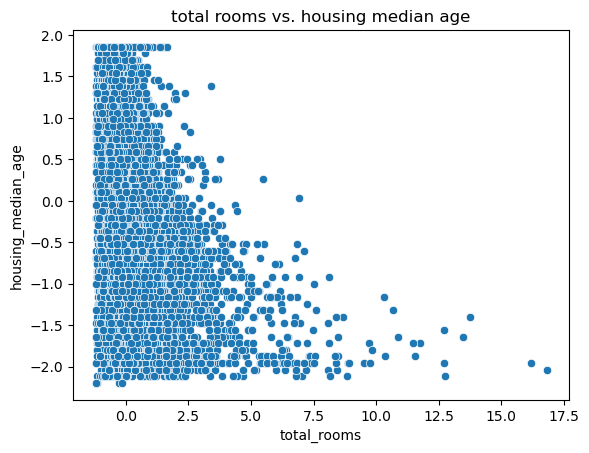

In [382]:
sns.scatterplot(data=X2_scaled, x=X2_scaled.total_rooms, y=X2_scaled.housing_median_age)
plt.title('total rooms vs. housing median age')
plt.show()

In [384]:
best_dict3 = get_scores_and_labels(combinations, X2_scaled)
best_dict3

Combination (0.1, 2) on iteration 1 of 360 has 64 clusters. Moving on
Index: 1, Score: 0.02637926529861901, Labels: [0 0 0 ... 0 0 0], NumClusters: 37
Index: 2, Score: 0.031071254226247985, Labels: [0 0 0 ... 0 0 0], NumClusters: 26
Index: 3, Score: 0.17074460909663958, Labels: [0 0 0 ... 0 0 0], NumClusters: 17
Index: 4, Score: 0.28578825110993905, Labels: [0 0 0 ... 0 0 0], NumClusters: 10
Index: 5, Score: 0.17389503132825726, Labels: [0 0 0 ... 0 0 0], NumClusters: 13
Index: 6, Score: 0.42069134026913413, Labels: [0 0 0 ... 0 0 0], NumClusters: 10
Index: 7, Score: 0.42051211084726187, Labels: [0 0 0 ... 0 0 0], NumClusters: 11
Index: 8, Score: 0.42658730396349476, Labels: [0 0 0 ... 0 0 0], NumClusters: 6
Index: 9, Score: 0.4296088287282281, Labels: [0 0 0 ... 0 0 0], NumClusters: 4
Index: 10, Score: 0.3646895681241411, Labels: [0 0 0 ... 0 0 0], NumClusters: 5
Index: 11, Score: 0.07217425566159094, Labels: [0 6 0 ... 0 0 0], NumClusters: 8
Index: 12, Score: 0.023806260361819372, La

{'best_epsilon': 1.0,
 'best_min_samples': 2,
 'best_labels': array([0, 0, 0, ..., 0, 0, 0], dtype=int64),
 'best_score': 0.8999444401810237}

In [386]:
model = DBSCAN(eps=1, min_samples=2).fit(X2_scaled)
silhouette_score(X2_scaled, model.labels_)

0.8999444401810237

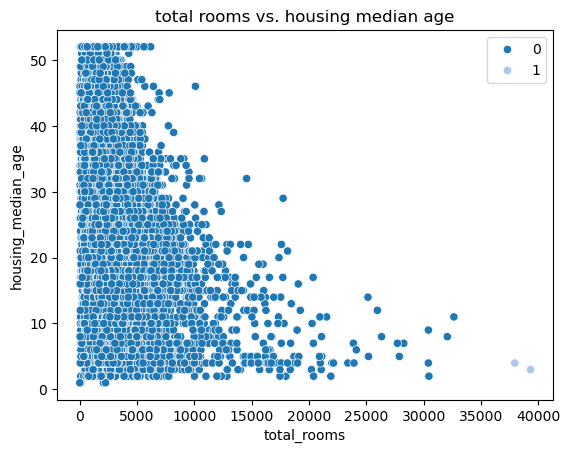

In [390]:
sns.scatterplot(data=df, x=df.total_rooms, y=df.housing_median_age, hue=model.labels_, palette='tab20')
plt.title('total rooms vs. housing median age')
plt.show()

In [412]:
from sklearn.metrics import silhouette_score
from sklearn.model_selection import GridSearchCV
from sklearn.cluster import DBSCAN
import numpy as np

def silhouette_scorer(estimator, X):
    labels = estimator.fit_predict(X)
    # في حالة جميع النقاط في نفس العنقود يكون Silhouette غير معرف، نعيد قيمة سيئة
    if len(set(labels)) <= 1 or -1 in set(labels) and len(set(labels)) == 1:
        return -1
    return silhouette_score(X, labels)

dbscan = DBSCAN()

param_grid = {
    'eps': epsilons,
    'min_samples': min_samples
}

grid = GridSearchCV(dbscan, param_grid, scoring=silhouette_scorer, cv=[(slice(None), slice(None))], refit=True)
grid.fit(X)

print("أفضل معلمات:", grid.best_params_)
print("أفضل قيمة مقياس silhouette:", grid.best_score_)
print("التسميات الخاصة بأفضل نموذج:", grid.best_estimator_.labels_)


أفضل معلمات: {'eps': 0.7631578947368421, 'min_samples': 15}
أفضل قيمة مقياس silhouette: 0.41463805720037145
التسميات الخاصة بأفضل نموذج: [0 0 0 ... 0 0 0]


In [414]:
 model = DBSCAN(eps=0.7631578947368421, min_samples=15).fit(X2_scaled)
silhouette_score(X2_scaled, model.labels_)

0.8492135802463886

In [416]:
 model = DBSCAN(eps=0.7631578947368421, min_samples=15).fit(X)
silhouette_score(X, model.labels_)

0.41463805720037145